In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from imblearn.under_sampling import RandomUnderSampler

In [2]:
df = pd.read_excel('DATASET_HOSPITAL_LABELED_CASEFOLD.xlsx')

In [3]:
df.head()

,review,sentiment
0,istri saya sissandra arisi dirawat setelah ope...,positive
1,"tq dr titos, dr suskhan dan suster pelayanan y...",positive
2,suster isti di bagian pendaftaran poliklinik n...,positive
3,"thank you utk dr. titos , dr. tjien ronny & al...",positive
4,terimaksih kepada dokter fery darmawan spog yg...,positive


In [4]:
df['panjang_review'] = df['review'].apply(lambda x: len(str(x).split()))

print("Statistik Deskriptif Panjang Review:")
print(df['panjang_review'].describe())
print(f"\nRata-rata panjang review : {df['panjang_review'].mean():.2f} kata")
print(f"Review terpendek         : {df['panjang_review'].min()} kata")
print(f"Review terpanjang        : {df['panjang_review'].max()} kata")

Statistik Deskriptif Panjang Review:
count    25295.000000
mean        29.283178
std         29.095332
min          1.000000
25%         15.000000
50%         26.000000
75%         37.000000
max        679.000000
Name: panjang_review, dtype: float64

Rata-rata panjang review : 29.28 kata
Review terpendek         : 1 kata
Review terpanjang        : 679 kata


In [5]:
df = df.drop('panjang_review', axis=1) 

In [6]:
df.head()

,review,sentiment
0,istri saya sissandra arisi dirawat setelah ope...,positive
1,"tq dr titos, dr suskhan dan suster pelayanan y...",positive
2,suster isti di bagian pendaftaran poliklinik n...,positive
3,"thank you utk dr. titos , dr. tjien ronny & al...",positive
4,terimaksih kepada dokter fery darmawan spog yg...,positive


Distribusi kelas:
sentiment
positive    20259
negative     5036
Name: count, dtype: int64

Total data: 25295

Proporsi kelas:
sentiment
positive    80.090927
negative    19.909073
Name: proportion, dtype: float64


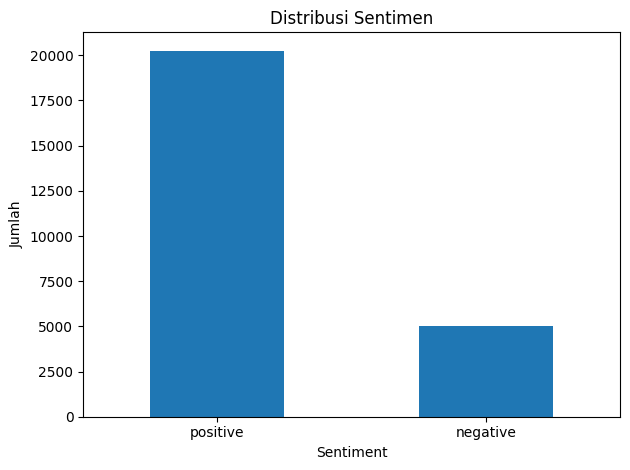

In [7]:
print("Distribusi kelas:")
print(df['sentiment'].value_counts())
print(f"\nTotal data: {len(df)}")

print("\nProporsi kelas:")
print(df["sentiment"].value_counts(normalize=True) * 100)

df["sentiment"].value_counts().plot(kind="bar")
plt.title("Distribusi Sentimen")
plt.xlabel("Sentiment")
plt.ylabel("Jumlah")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [8]:
def case_folding(text):
    if isinstance(text, str):
        text = text.lower()
        return text
    return text

df['review'] = df['review'].apply(case_folding)

In [9]:
null_data = df.isna().sum()
print(null_data)

review       0
sentiment    0
dtype: int64


In [10]:
duplicated_rows = df[df.duplicated()]
print(f"Total duplikat: {len(duplicated_rows)}")

print("\nDuplikat per kelas:")
print(duplicated_rows['sentiment'].value_counts())

Total duplikat: 1375

Duplikat per kelas:
sentiment
positive    1215
negative     160
Name: count, dtype: int64


In [11]:
df = df.drop_duplicates()
duplicated = df.duplicated().sum()
print(duplicated)

0


In [12]:
df['sentiment'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})

df.head()

,review,sentiment
0,istri saya sissandra arisi dirawat setelah ope...,1
1,"tq dr titos, dr suskhan dan suster pelayanan y...",1
2,suster isti di bagian pendaftaran poliklinik n...,1
3,"thank you utk dr. titos , dr. tjien ronny & al...",1
4,terimaksih kepada dokter fery darmawan spog yg...,1


In [13]:
rus = RandomUnderSampler(random_state=5)

feature_cols = df.columns[:768].tolist()
X_temp = df[feature_cols]
y_temp = df['sentiment']

X_res, y_res = rus.fit_resample(X_temp, y_temp)

df = pd.DataFrame(X_res, columns=feature_cols)
df['sentiment'] = y_res

print("Setelah undersample:", df['sentiment'].value_counts())

Setelah undersample: sentiment
0    4876
1    4876
Name: count, dtype: int64


In [14]:
import torch
from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained("indobenchmark/indobert-base-p1")
model = AutoModel.from_pretrained("indobenchmark/indobert-base-p1")
model.eval()

def indobert_embed(texts, batch_size=32):
    all_embeddings = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]

        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors="pt"
        )

        with torch.no_grad():
            outputs = model(**inputs)

        emb = outputs.last_hidden_state[:, 0, :]
        all_embeddings.append(emb)

    return torch.cat(all_embeddings).numpy()

X = indobert_embed(df["review"].tolist())

df_embed = pd.DataFrame(X)

df_final = pd.concat(
    [df_embed,
     df["sentiment"].reset_index(drop=True)],
    axis=1
)

save_path = "C:/Users/David/SKIRPSI/UNDERSAMPLING FIX/data_clean.csv"
df_final.to_csv(save_path, index=False)

print("File berhasil disimpan di:")
print(save_path)


File berhasil disimpan di:
C:/Users/David/SKIRPSI/UNDERSAMPLING FIX/data_clean.csv
